In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv('heart.csv')

heart_df = pd.DataFrame(data)
heart_df.head()


###------ feature engineering
X = heart_df.drop('target',axis = 1)
Y = heart_df['target']

###---------train-test
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

###---------data transform scalar
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

###--------model training
from sklearn.neighbors import KNeighborsClassifier
knn_classifier = KNeighborsClassifier(n_neighbors=3)
knn_classifier.fit(X_train_scaled,Y_train)
 
###----------predict
y_p = knn_classifier.predict(X_test_scaled)


from sklearn.metrics import precision_score,recall_score,accuracy_score
recall_score(Y_test,y_p)



179    0
228    0
111    1
246    0
60     1
      ..
249    0
104    1
300    0
193    0
184    0
Name: target, Length: 61, dtype: int64

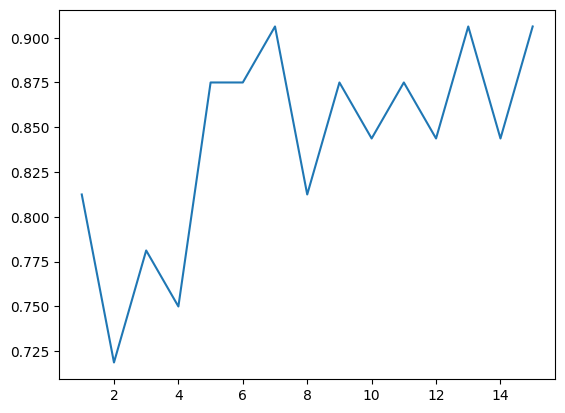

ValueError: Data must be 1-dimensional, got ndarray of shape (242, 13) instead

In [ ]:
###----------use cross validation to improve accuracy_score


score = []
for i in range(1,16):
    knn_classifier = KNeighborsClassifier(n_neighbors=i)
    knn_classifier.fit(X_train_scaled,Y_train)
    y_p = knn_classifier.predict(X_test_scaled)
    score.append(recall_score(Y_test,y_p))
import matplotlib.pyplot as plt
plt.plot(range(1,16),score)
plt.show()

import seaborn as sns
sns.scatterplot(x=X_train,y=Y_train,hue='data=')




 